# Supplemental Code for Lesson 4

```bash
pip install numpy scikit-learn xgboost
```

**Datasets:**
- Part 1: `train.csv` from house-prices-advanced-regression-techniques (already downloaded)
- Part 2: digit-recognizer competition on Kaggle

```bash
kaggle competitions download -c digit-recognizer
unzip digit-recognizer.zip
```

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, r2_score
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor, XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

---
# Part 1 — House Prices: Beating the Linear Baseline

In Lesson 3 we built a Linear Regression baseline with RMSE ~0.174 and Kaggle score 0.17347.

The residual plot showed a clear pattern — the model underpredicts expensive houses and overpredicts cheap ones.
That's a non-linearity problem. Linear models assume a straight-line relationship between features and price.
Reality is not a straight line.

**Today's goal:** beat 0.17347 on Kaggle using Random Forest and XGBoost.

## 1.1 — Quick EDA Recap

We already explored this dataset in Lesson 3. Quick sanity check only, then straight to modeling.

In [ ]:
houses = pd.read_csv("_house-prices/train.csv")

print("Shape:", houses.shape)
print("\nTarget — SalePrice:")
print(houses["SalePrice"].describe().apply(lambda x: f"${x:,.0f}"))
print(f"\nSkew: {houses['SalePrice'].skew():.3f}  →  we predict LogSalePrice as in Lesson 3")

Shape: (1460, 81)

Target — SalePrice:
count      $1,460
mean     $180,921
std       $79,443
min       $34,900
25%      $129,975
50%      $163,000
75%      $214,000
max      $755,000
Name: SalePrice, dtype: str

Skew: 1.883  →  we predict LogSalePrice as in Lesson 3


In [23]:
# Same cleaning pipeline as Lesson 3
# Drop columns with more than 40% missing, impute the rest
threshold = 0.40
cols_to_drop = houses.isnull().mean()[houses.isnull().mean() > threshold].index
houses_clean = houses.drop(columns=cols_to_drop)

num_cols = houses_clean.select_dtypes(include="number").columns
houses_clean[num_cols] = houses_clean[num_cols].fillna(houses_clean[num_cols].median())

cat_cols = houses_clean.select_dtypes(include="object").columns
for col in cat_cols:
    houses_clean[col] = houses_clean[col].fillna(houses_clean[col].mode()[0])

print(f"Dropped {len(cols_to_drop)} high-missing columns: {list(cols_to_drop)}")
print(f"Shape after cleaning: {houses_clean.shape}")
print(f"Missing values remaining: {houses_clean.isnull().sum().sum()}")

# Save training imputation values — reuse these on the test set to avoid leakage
train_num_medians = houses_clean[num_cols].median()
train_cat_modes   = {col: houses_clean[col].mode()[0] for col in cat_cols}

Dropped 6 high-missing columns: ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']
Shape after cleaning: (1460, 75)
Missing values remaining: 0


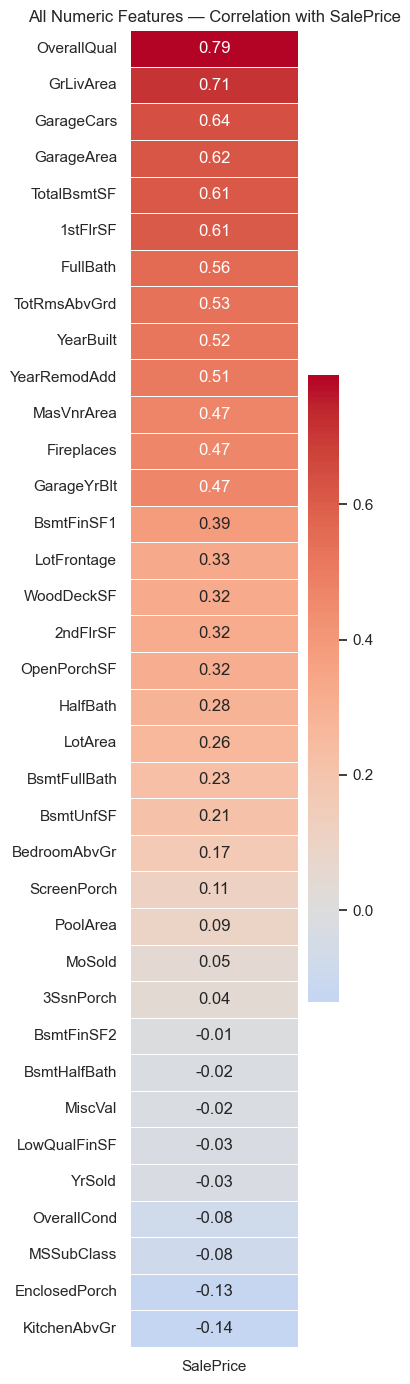

In [24]:
# Correlation heatmap — all numeric features vs SalePrice
numeric_cols = houses_clean.select_dtypes(include="number").drop(columns=["Id", "SalePrice"]).columns
corr_all = houses_clean[list(numeric_cols) + ["SalePrice"]].corr()[["SalePrice"]].drop("SalePrice").sort_values("SalePrice", ascending=False)

plt.figure(figsize=(4, 14))
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("All Numeric Features — Correlation with SalePrice")
plt.tight_layout()
plt.show()

## 1.2 — Feature Engineering

In Lesson 3 we hand-picked 7 features. Today we use all numeric features plus one-hot encoded categoricals.

Tree-based models handle many features well — they select the most useful ones at each split automatically.
More features = more signal to exploit.

In [25]:
# Log-transform the target
houses_clean["LogSalePrice"] = np.log1p(houses_clean["SalePrice"])

# One-hot encode all categorical features
houses_encoded = pd.get_dummies(houses_clean, drop_first=False)

FEATURES = [c for c in houses_encoded.columns if c not in ["SalePrice", "LogSalePrice", "Id"]]
TARGET   = "LogSalePrice"

X = houses_encoded[FEATURES]
y = houses_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Features after one-hot encoding: {len(FEATURES)}")
print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows:     {X_test.shape[0]}")

Features after one-hot encoding: 266
Training rows: 1168
Test rows:     292


## 1.3 — Overfitting: Seeing It Happen First

Before jumping to Random Forest, let's understand the problem it solves.

A single Decision Tree splits data by asking yes/no questions on features.
With no depth limit, it can perfectly memorise every training example — including noise.
This is **overfitting**: perfect train score, poor test score.

The gap between train error and test error is the diagnostic:
- Small gap → healthy generalisation
- Large gap → overfitting

In [26]:
depths = [2, 4, 6, 8, 10, 15, 20, None]
train_scores, test_scores = [], []

for depth in depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, dt.predict(X_train)))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  dt.predict(X_test)))
    train_scores.append(train_rmse)
    test_scores.append(test_rmse)
    label = str(depth) if depth else "None"
    print(f"  max_depth={label:>4}  |  Train RMSE: {train_rmse:.4f}  |  Test RMSE: {test_rmse:.4f}  |  Gap: {test_rmse - train_rmse:.4f}")

  max_depth=   2  |  Train RMSE: 0.2439  |  Test RMSE: 0.2646  |  Gap: 0.0207
  max_depth=   4  |  Train RMSE: 0.1840  |  Test RMSE: 0.2069  |  Gap: 0.0229
  max_depth=   6  |  Train RMSE: 0.1328  |  Test RMSE: 0.1939  |  Gap: 0.0611
  max_depth=   8  |  Train RMSE: 0.0807  |  Test RMSE: 0.1904  |  Gap: 0.1097
  max_depth=  10  |  Train RMSE: 0.0421  |  Test RMSE: 0.1982  |  Gap: 0.1562
  max_depth=  15  |  Train RMSE: 0.0062  |  Test RMSE: 0.1952  |  Gap: 0.1890
  max_depth=  20  |  Train RMSE: 0.0005  |  Test RMSE: 0.1894  |  Gap: 0.1889
  max_depth=None  |  Train RMSE: 0.0000  |  Test RMSE: 0.1841  |  Gap: 0.1841


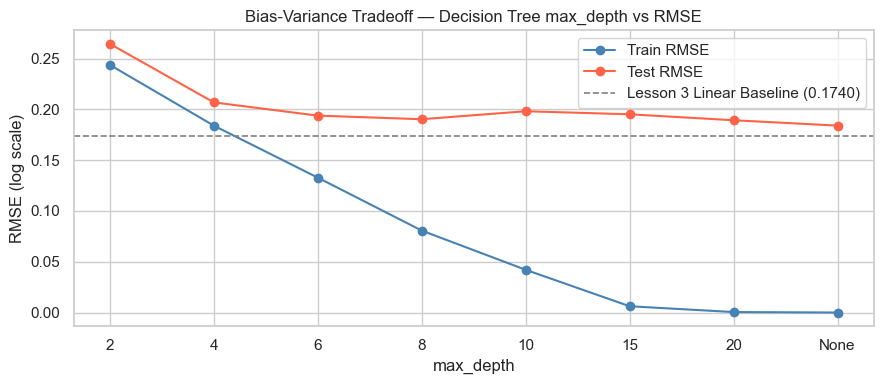


Interpretation:
  Low depth   →  underfitting (both train and test error are high)
  High depth  →  overfitting  (train error → 0, test error grows)
  The sweet spot is somewhere in between — Random Forest finds it automatically


In [27]:
depth_labels = [str(d) if d else "None" for d in depths]

plt.figure(figsize=(9, 4))
plt.plot(depth_labels, train_scores, marker="o", label="Train RMSE", color="steelblue")
plt.plot(depth_labels, test_scores,  marker="o", label="Test RMSE",  color="tomato")
plt.axhline(0.1740, color="gray", linestyle="--", linewidth=1.2, label="Lesson 3 Linear Baseline (0.1740)")
plt.xlabel("max_depth")
plt.ylabel("RMSE (log scale)")
plt.title("Bias-Variance Tradeoff — Decision Tree max_depth vs RMSE")
plt.legend()
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  Low depth   →  underfitting (both train and test error are high)")
print("  High depth  →  overfitting  (train error → 0, test error grows)")
print("  The sweet spot is somewhere in between — Random Forest finds it automatically")

## 1.4 — Random Forest

Random Forest solves overfitting by building many trees, each trained on:
- A **random subset of rows** (bootstrap sampling — sampling with replacement)
- A **random subset of features** at each split

Each individual tree overfits differently. When you average their predictions, the noise cancels and the signal remains.
This is called **ensemble learning** — the wisdom of crowds applied to decision trees.

Key parameters:
- `n_estimators` — number of trees (more is generally better, diminishing returns after ~200)
- `max_depth` — how deep each tree can grow (None = unlimited, relies on bootstrapping for regularisation)
- `max_features` — how many features to consider at each split ("sqrt" is a good default for classification)

In [28]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("=" * 50)
print(f"  Lesson 3 Linear Regression RMSE : 0.1740")
print(f"  Random Forest RMSE              : {rmse_rf:.4f}  ({'-' if rmse_rf < 0.1740 else '+'}{ abs(rmse_rf - 0.1740):.4f} vs baseline)")
print(f"  R² Score                        : {r2_rf:.3f}")
print("=" * 50)

  Lesson 3 Linear Regression RMSE : 0.1740
  Random Forest RMSE              : 0.1445  (-0.0295 vs baseline)
  R² Score                        : 0.888


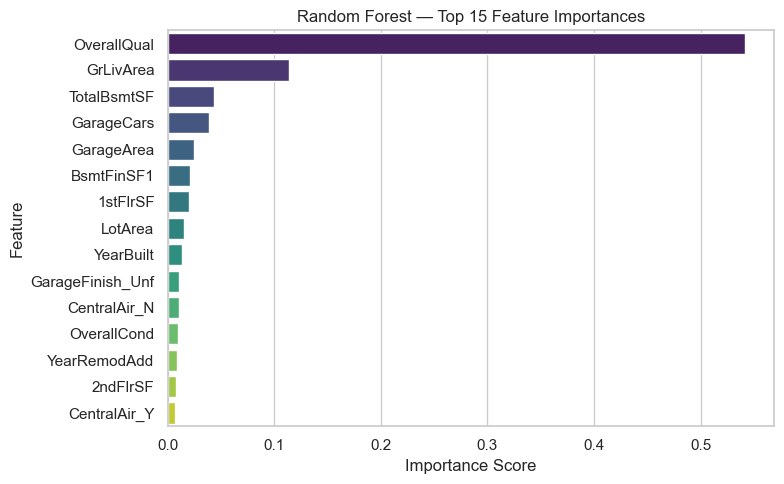

In [29]:
# Feature importance — what does Random Forest think matters most?
importance_df = pd.DataFrame({
    "Feature":    FEATURES,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")
plt.title("Random Forest — Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

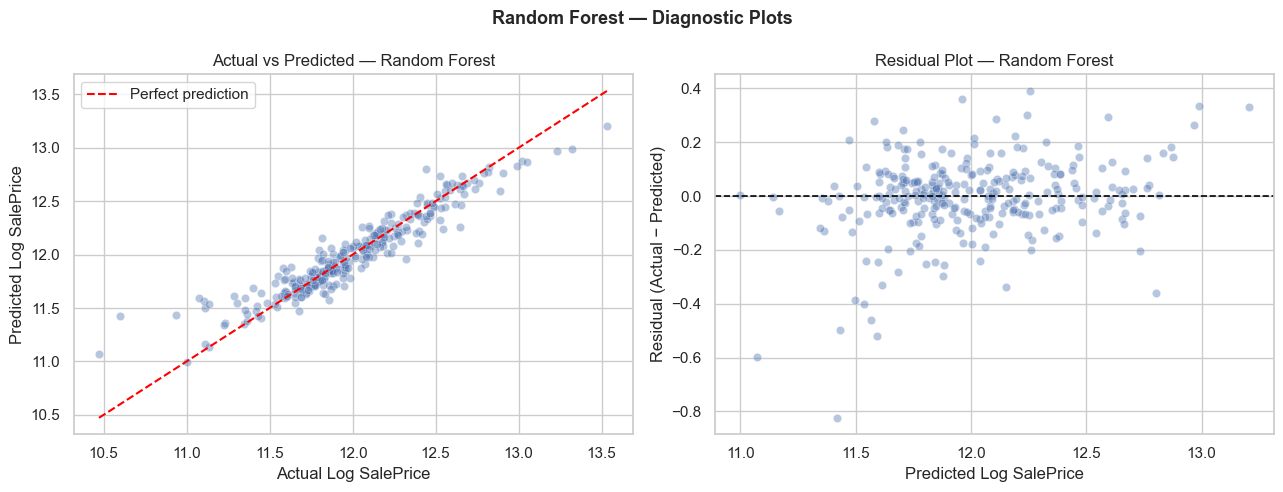

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
residuals_rf = y_test - y_pred_rf

sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.4, ax=axes[0])
min_val, max_val = y_test.min(), y_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], color="red", linewidth=1.5, linestyle="--", label="Perfect prediction")
axes[0].set_xlabel("Actual Log SalePrice")
axes[0].set_ylabel("Predicted Log SalePrice")
axes[0].set_title("Actual vs Predicted — Random Forest")
axes[0].legend()

sns.scatterplot(x=y_pred_rf, y=residuals_rf, alpha=0.4, ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1.2, linestyle="--")
axes[1].set_xlabel("Predicted Log SalePrice")
axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].set_title("Residual Plot — Random Forest")

plt.suptitle("Random Forest — Diagnostic Plots", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 1.5 — XGBoost

Random Forest builds trees **in parallel** — each tree is independent.

XGBoost builds trees **sequentially**. Each new tree is trained to predict the **residual errors** of all previous trees combined.
This is called **gradient boosting** — trees are added in the direction that reduces the loss fastest.

```
Tree 1  →  predicts SalePrice, makes errors
Tree 2  →  trained on the errors of Tree 1
Tree 3  →  trained on the errors of Trees 1 + 2
...and so on for n_estimators rounds
```

Final prediction = sum of all trees weighted by learning_rate.

Key parameters:
- `n_estimators` — number of boosting rounds (more = better, but risks overfitting without early stopping)
- `learning_rate` — how much each tree contributes (lower = more conservative, needs more trees)
- `max_depth` — shallower trees generalise better in boosting (3–6 is typical)
- `subsample` — fraction of rows per tree, like RF's bootstrap

In [31]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print(f"Stopped at round {xgb.best_iteration} (out of 500)")

y_pred_xgb = xgb.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("=" * 50)
print(f"  Lesson 3 Linear Regression RMSE : 0.1740")
print(f"  Random Forest RMSE              : {rmse_rf:.4f}")
print(f"  XGBoost RMSE                    : {rmse_xgb:.4f}  ({'-' if rmse_xgb < 0.1740 else '+'}{ abs(rmse_xgb - 0.1740):.4f} vs baseline)")
print(f"  XGBoost R²                      : {r2_xgb:.3f}")
print("=" * 50)

Stopped at round 263 (out of 500)
  Lesson 3 Linear Regression RMSE : 0.1740
  Random Forest RMSE              : 0.1445
  XGBoost RMSE                    : 0.1290  (-0.0450 vs baseline)
  XGBoost R²                      : 0.911


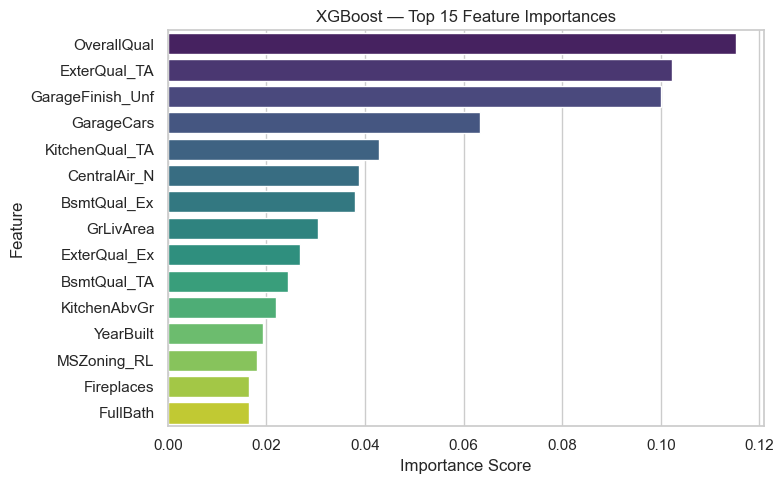

In [32]:
# XGBoost feature importance
xgb_importance_df = pd.DataFrame({
    "Feature":    FEATURES,
    "Importance": xgb.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(8, 5))
sns.barplot(data=xgb_importance_df, x="Importance", y="Feature", palette="viridis")
plt.title("XGBoost — Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## 1.6 — Hyperparameter Tuning

Model parameters like `max_depth` and `n_estimators` are not learned from data — you set them manually.
These are called **hyperparameters**.

**Grid Search** — tries every combination in the grid. Thorough but exponentially slow.

**Random Search** — samples N random combinations. Finds good results in a fraction of the time.
Research shows random search finds equally good or better hyperparameters than grid search for the same compute budget.

Rule of thumb: start with random search to find the best region, then optionally fine-tune with grid search.

In [33]:
param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [3, 4, 5, 6, None],
    "min_samples_split": [2, 5, 10],
    "max_features":      ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    verbose=1
)
rf_search.fit(X_train, y_train)

print(f"\nBest params: {rf_search.best_params_}")
print(f"Best CV RMSE: {-rf_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV RMSE: 0.1464


In [34]:
best_rf = rf_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
rmse_best_rf = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))

print("=" * 55)
print(f"  Lesson 3 Linear Regression RMSE : 0.1740  (Kaggle: 0.17347)")
print(f"  Random Forest (default) RMSE    : {rmse_rf:.4f}")
print(f"  Random Forest (tuned)   RMSE    : {rmse_best_rf:.4f}")
print(f"  XGBoost (default)       RMSE    : {rmse_xgb:.4f}")
print("=" * 55)

  Lesson 3 Linear Regression RMSE : 0.1740  (Kaggle: 0.17347)
  Random Forest (default) RMSE    : 0.1445
  Random Forest (tuned)   RMSE    : 0.1575
  XGBoost (default)       RMSE    : 0.1290


## 1.7 — Kaggle Submission

In [ ]:
test = pd.read_csv("_house-prices/test.csv")

# Apply same cleaning pipeline
test_clean = test.drop(columns=[c for c in cols_to_drop if c in test.columns], errors="ignore")

# Impute using training statistics — using test statistics here would be data leakage
t_num = test_clean.select_dtypes(include="number").columns
t_cat = test_clean.select_dtypes(include="object").columns
test_clean[t_num] = test_clean[t_num].fillna(train_num_medians)
for col in t_cat:
    if col in train_cat_modes:
        test_clean[col] = test_clean[col].fillna(train_cat_modes[col])

test_encoded = pd.get_dummies(test_clean, drop_first=False)

# Align columns with training set
test_encoded = test_encoded.reindex(columns=FEATURES, fill_value=0)

log_preds     = best_rf.predict(test_encoded)
predicted_prices = np.expm1(log_preds)

submission = pd.DataFrame({"Id": test["Id"], "SalePrice": predicted_prices})
submission.to_csv("house_prices_rf_submission.csv", index=False)

print(f"Predictions generated for {len(submission)} houses")
print(f"  Min:    ${predicted_prices.min():>12,.0f}")
print(f"  Median: ${np.median(predicted_prices):>12,.0f}")
print(f"  Mean:   ${predicted_prices.mean():>12,.0f}")
print(f"  Max:    ${predicted_prices.max():>12,.0f}")
print(f"\n✓ Saved as 'house_prices_rf_submission.csv'")

Predictions generated for 1459 houses
  Min:    $      69,597
  Median: $     156,005
  Mean:   $     174,793
  Max:    $     420,438

✓ Saved as 'house_prices_rf_submission.csv'


## Submit to Kaggle

```bash
kaggle competitions submit -c house-prices-advanced-regression-techniques -f house_prices_rf_submission.csv -m "Lesson 4 - tuned Random Forest"
```

---
# Part 2 — MNIST Digit Recognition

## What is image data?

A grayscale image is a grid of pixel values, each between 0 (black) and 255 (white).
MNIST images are 28×28 pixels = **784 features per image**.
Each row in the dataset is one flattened image.

```
Image (28×28 grid):      Flattened row (784 values):
┌───────────────┐
│  0   0   0 ...│  →  [0, 0, 0, 12, 254, 200, 0, 0, ... ]
│  0  12 254 ...│
│  ...          │
└───────────────┘
```

The task: given 784 pixel values, predict which digit (0–9) the image shows.
This is a **10-class classification** problem.

Join the competition first: kaggle.com/c/digit-recognizer

```bash
kaggle competitions download -c digit-recognizer
unzip digit-recognizer.zip
```

## 2.1 — Load the Data

In [43]:
digits_train = pd.read_csv("_digit-recognizer/train.csv")
digits_test  = pd.read_csv("_digit-recognizer/test.csv")

print("Train shape:", digits_train.shape)
print("Test shape: ", digits_test.shape)
print(f"\nFeatures per image: {digits_train.shape[1] - 1}  (28×28 pixels)")
print("\nLabel distribution:")
print(digits_train["label"].value_counts().sort_index())

Train shape: (42000, 785)
Test shape:  (28000, 784)

Features per image: 784  (28×28 pixels)

Label distribution:
label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


## 2.2 — Quick EDA: Visualise the Images

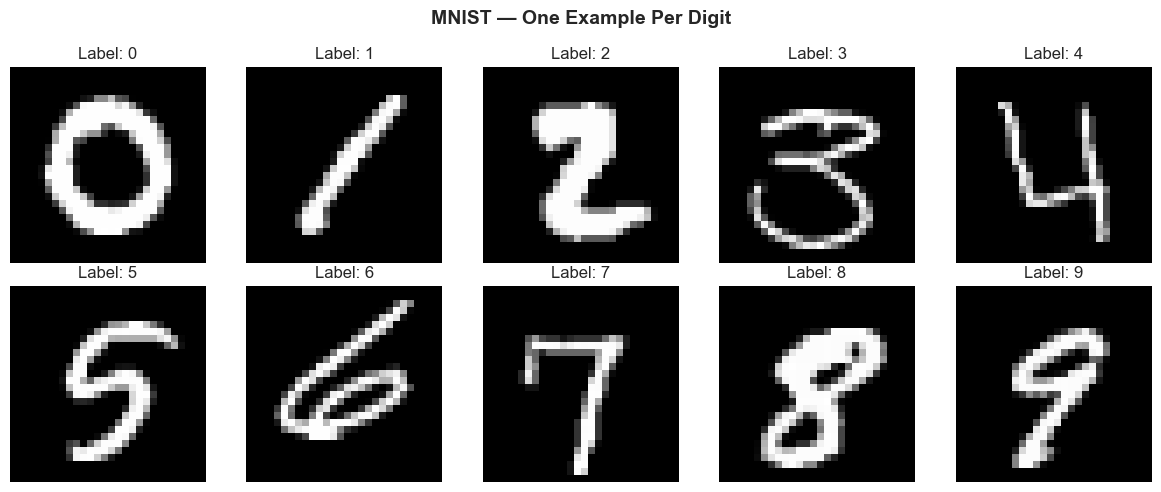

In [44]:
# Show one example per digit
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for digit in range(10):
    sample = digits_train[digits_train["label"] == digit].iloc[0]
    pixels = sample.drop("label").values.reshape(28, 28)
    axes[digit].imshow(pixels, cmap="gray")
    axes[digit].set_title(f"Label: {digit}", fontsize=12)
    axes[digit].axis("off")

plt.suptitle("MNIST — One Example Per Digit", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

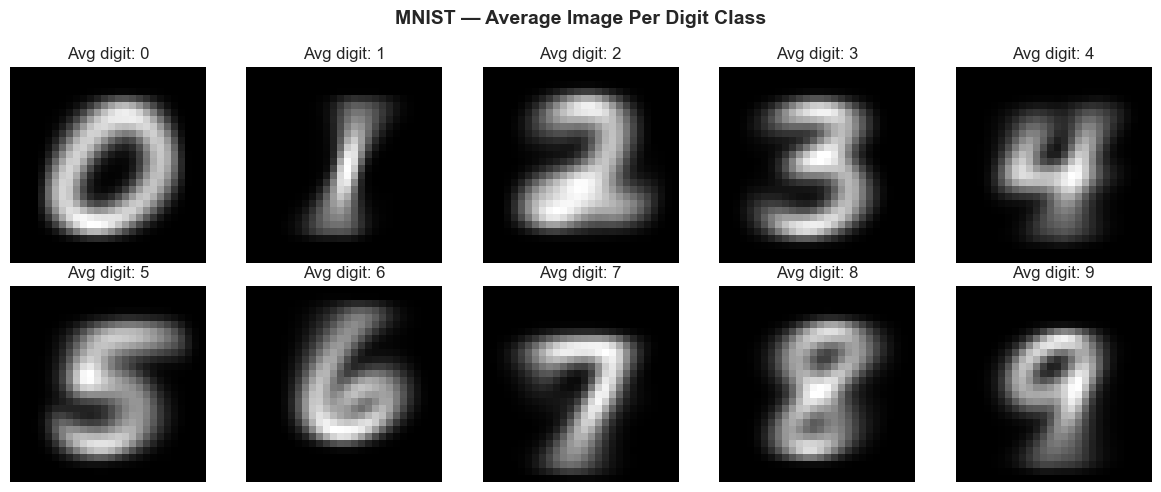

In [45]:
# Average pixel intensity per digit — what does a typical 3 look like?
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for digit in range(10):
    avg = digits_train[digits_train["label"] == digit].drop(columns="label").mean().values.reshape(28, 28)
    axes[digit].imshow(avg, cmap="gray")
    axes[digit].set_title(f"Avg digit: {digit}")
    axes[digit].axis("off")

plt.suptitle("MNIST — Average Image Per Digit Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [46]:
# Prepare features and target
X_digits = digits_train.drop(columns=["label"]).values / 255.0  # normalise to 0-1
y_digits = digits_train["label"].values

X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42, stratify=y_digits
)

print(f"Training images: {X_d_train.shape[0]}")
print(f"Test images:     {X_d_test.shape[0]}")
print(f"Features per image: {X_d_train.shape[1]}  (28×28 pixels)")

Training images: 33600
Test images:     8400
Features per image: 784  (28×28 pixels)


## 2.3 — The Dimensionality Problem → PCA

784 features is a lot. Many pixels are almost always 0 (corners, edges) and carry no information.
Training on 784 features is slow and the redundant features add noise.

This is the **curse of dimensionality**: as the number of features grows, data becomes increasingly sparse
and models need exponentially more data to learn well.

**PCA (Principal Component Analysis)** finds the directions of maximum variance in the data
and projects onto a smaller number of dimensions.

Each PCA component is a linear combination of original features that captures the most remaining variance.
The first component captures the most variance, the second the next most, and so on.

```
784 raw pixel features  →  PCA  →  100 components  (~91% of variance retained)
```

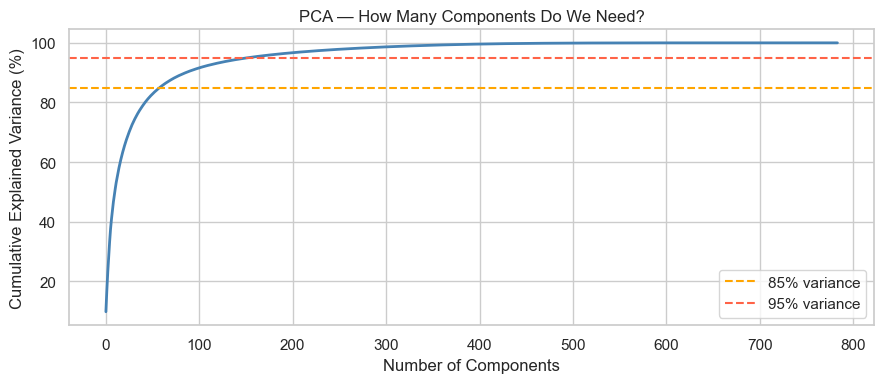

Components to reach 85% variance: 59  (down from 784)
Components to reach 95% variance: 153  (down from 784)


In [47]:
# How much variance does each additional component capture?
pca_full = PCA(random_state=42)
pca_full.fit(X_d_train)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(9, 4))
plt.plot(cumvar, linewidth=2, color="steelblue")
plt.axhline(85, color="orange", linestyle="--", label="85% variance")
plt.axhline(95, color="tomato",  linestyle="--", label="95% variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA — How Many Components Do We Need?")
plt.legend()
plt.tight_layout()
plt.show()

n_85 = np.argmax(cumvar >= 85) + 1
n_95 = np.argmax(cumvar >= 95) + 1
print(f"Components to reach 85% variance: {n_85}  (down from 784)")
print(f"Components to reach 95% variance: {n_95}  (down from 784)")

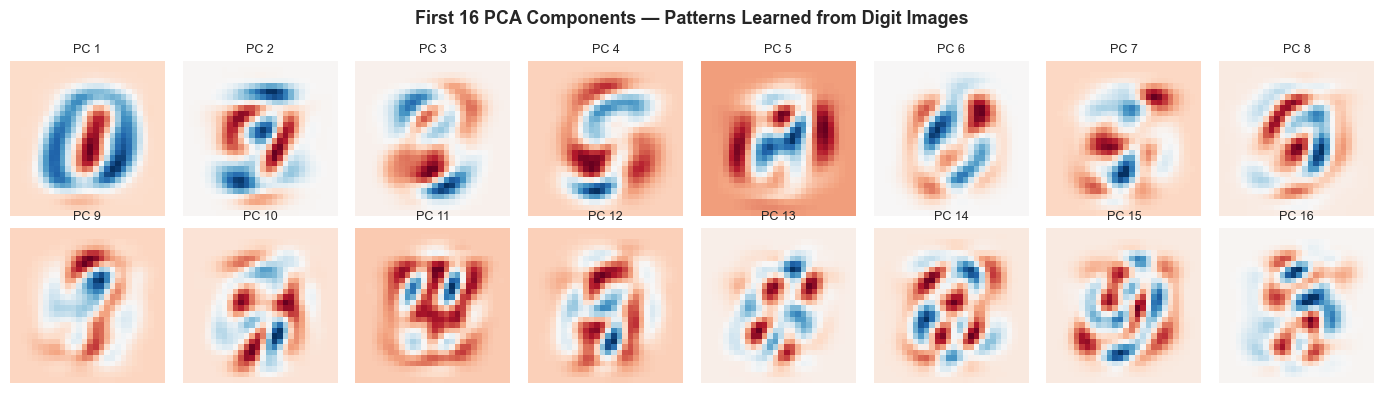

In [48]:
# Visualise the PCA components — the 'eigendigits'
# Each component is a pattern that PCA found in the data
pca_vis = PCA(n_components=16, random_state=42)
pca_vis.fit(X_d_train)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
axes = axes.flatten()

for i, component in enumerate(pca_vis.components_):
    axes[i].imshow(component.reshape(28, 28), cmap="RdBu")
    axes[i].set_title(f"PC {i+1}", fontsize=9)
    axes[i].axis("off")

plt.suptitle("First 16 PCA Components — Patterns Learned from Digit Images", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

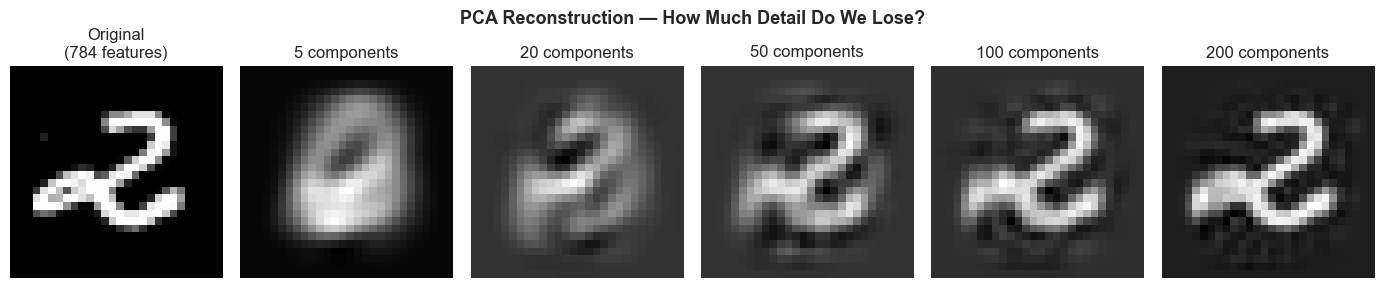

In [50]:
# Reconstruction — what do we lose at different compression levels?
sample_image = X_d_train[0]

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
axes[0].imshow(sample_image.reshape(28, 28), cmap="gray")
axes[0].set_title("Original\n(784 features)")
axes[0].axis("off")

for i, n_comp in enumerate([5, 20, 50, 100, 200]):
    pca_temp = PCA(n_components=n_comp, random_state=42)
    pca_temp.fit(X_d_train)
    compressed    = pca_temp.transform([sample_image])
    reconstructed = pca_temp.inverse_transform(compressed)
    axes[i+1].imshow(reconstructed.reshape(28, 28), cmap="gray")
    axes[i+1].set_title(f"{n_comp} components")
    axes[i+1].axis("off")

plt.suptitle("PCA Reconstruction — How Much Detail Do We Lose?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 2.4 — Random Forest on PCA-Compressed Images

In [51]:
# Apply PCA — 784 → 100 components
N_COMPONENTS = 100

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_d_train_pca = pca.fit_transform(X_d_train)
X_d_test_pca  = pca.transform(X_d_test)

var_explained = pca.explained_variance_ratio_.sum() * 100
print(f"PCA: {X_d_train.shape[1]} features → {N_COMPONENTS} components")
print(f"Variance retained: {var_explained:.1f}%")

PCA: 784 features → 100 components
Variance retained: 91.5%


In [52]:
# Naive baseline
most_common  = pd.Series(y_d_train).mode()[0]
naive_acc_d = accuracy_score(y_d_test, np.full(len(y_d_test), most_common))
print(f"Naive baseline (always predict '{most_common}'): {naive_acc_d:.3f}")
print(f"With 10 balanced classes, random guessing ≈ 10%")

Naive baseline (always predict '1'): 0.112
With 10 balanced classes, random guessing ≈ 10%


In [53]:
rf_digits = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_digits.fit(X_d_train_pca, y_d_train)

y_d_pred_rf = rf_digits.predict(X_d_test_pca)
acc_rf_d = accuracy_score(y_d_test, y_d_pred_rf)

print("=" * 40)
print(f"  Naive baseline accuracy : {naive_acc_d:.3f}")
print(f"  Random Forest accuracy  : {acc_rf_d:.3f}")
print("=" * 40)
print(classification_report(y_d_test, y_d_pred_rf))

  Naive baseline accuracy : 0.112
  Random Forest accuracy  : 0.946
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       827
           1       0.98      0.98      0.98       937
           2       0.94      0.95      0.94       835
           3       0.92      0.93      0.92       870
           4       0.94      0.95      0.95       814
           5       0.93      0.92      0.93       759
           6       0.96      0.97      0.97       827
           7       0.96      0.96      0.96       880
           8       0.93      0.90      0.91       813
           9       0.93      0.92      0.93       838

    accuracy                           0.95      8400
   macro avg       0.95      0.95      0.95      8400
weighted avg       0.95      0.95      0.95      8400



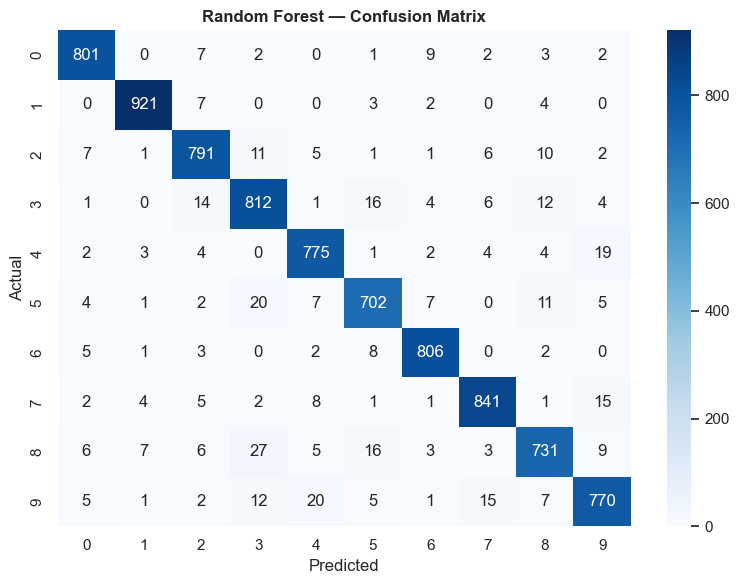


Most common confusions:
  Actual 0 predicted as 6: 9 times
  Actual 0 predicted as 2: 7 times
  Actual 1 predicted as 2: 7 times
  Actual 2 predicted as 3: 11 times
  Actual 2 predicted as 8: 10 times
  Actual 2 predicted as 0: 7 times
  Actual 2 predicted as 7: 6 times
  Actual 3 predicted as 5: 16 times
  Actual 3 predicted as 2: 14 times
  Actual 3 predicted as 8: 12 times
  Actual 3 predicted as 7: 6 times
  Actual 4 predicted as 9: 19 times
  Actual 5 predicted as 3: 20 times
  Actual 5 predicted as 8: 11 times
  Actual 5 predicted as 4: 7 times
  Actual 5 predicted as 6: 7 times
  Actual 6 predicted as 5: 8 times
  Actual 7 predicted as 9: 15 times
  Actual 7 predicted as 4: 8 times
  Actual 8 predicted as 3: 27 times
  Actual 8 predicted as 5: 16 times
  Actual 8 predicted as 9: 9 times
  Actual 8 predicted as 1: 7 times
  Actual 8 predicted as 0: 6 times
  Actual 8 predicted as 2: 6 times
  Actual 9 predicted as 4: 20 times
  Actual 9 predicted as 7: 15 times
  Actual 9 predic

In [54]:
# Confusion matrix — which digits does the model confuse?
cm = confusion_matrix(y_d_test, y_d_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest — Confusion Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nMost common confusions:")
for i in range(10):
    errors = [(j, cm[i,j]) for j in range(10) if j != i and cm[i,j] > 5]
    if errors:
        for j, count in sorted(errors, key=lambda x: -x[1]):
            print(f"  Actual {i} predicted as {j}: {count} times")

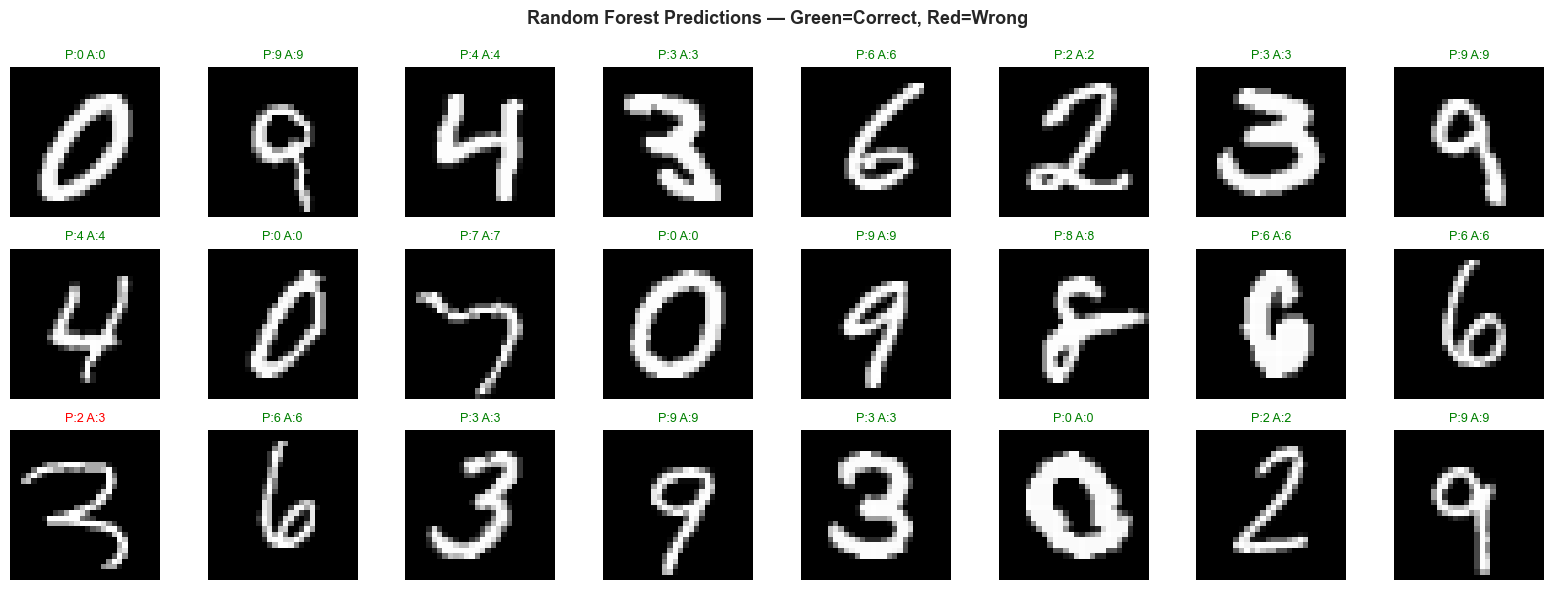

In [55]:
# Visualise sample predictions — green = correct, red = wrong
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
sample_idx = np.random.choice(len(X_d_test), 24, replace=False)

for i, idx in enumerate(sample_idx):
    row, col = i // 8, i % 8
    axes[row, col].imshow(X_d_test[idx].reshape(28, 28), cmap="gray")
    pred   = y_d_pred_rf[idx]
    actual = y_d_test[idx]
    color  = "green" if pred == actual else "red"
    axes[row, col].set_title(f"P:{pred} A:{actual}", color=color, fontsize=9)
    axes[row, col].axis("off")

plt.suptitle("Random Forest Predictions — Green=Correct, Red=Wrong", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 2.5 — XGBoost on Digits

In [58]:
xgb_digits = XGBClassifier(
    n_estimators=600,
    learning_rate=0.1,
    max_depth=5,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    eval_metric="mlogloss",
    random_state=42,
    verbosity=0
)
xgb_digits.fit(X_d_train_pca, y_d_train, eval_set=[(X_d_test_pca, y_d_test)], verbose=False)
print(f"Stopped at round {xgb_digits.best_iteration} (out of 600)")

y_d_pred_xgb = xgb_digits.predict(X_d_test_pca)
acc_xgb_d = accuracy_score(y_d_test, y_d_pred_xgb)

print("=" * 40)
print(f"  Naive baseline accuracy : {naive_acc_d:.3f}")
print(f"  Random Forest accuracy  : {acc_rf_d:.3f}")
print(f"  XGBoost accuracy        : {acc_xgb_d:.3f}")
print("=" * 40)

Stopped at round 599 (out of 600)
  Naive baseline accuracy : 0.112
  Random Forest accuracy  : 0.946
  XGBoost accuracy        : 0.967


## 2.6 — Kaggle Submission

In [59]:
X_submit     = digits_test.values / 255.0
X_submit_pca = pca.transform(X_submit)

submit_preds = rf_digits.predict(X_submit_pca)

submission_digits = pd.DataFrame({
    "ImageId": range(1, len(submit_preds) + 1),
    "Label":   submit_preds
})
submission_digits.to_csv("digit_submission.csv", index=False)

print(f"Predictions generated for {len(submission_digits)} images")
print(f"\nPrediction distribution:")
print(pd.Series(submit_preds).value_counts().sort_index().to_string())
print(f"\n✓ Saved as 'digit_submission.csv'")

Predictions generated for 28000 images

Prediction distribution:
0    2784
1    3210
2    2845
3    2852
4    2789
5    2491
6    2768
7    2885
8    2635
9    2741

✓ Saved as 'digit_submission.csv'


## Submit to Kaggle

```bash
kaggle competitions submit -c digit-recognizer -f digit_submission.csv -m "Lesson 4 - PCA + Random Forest"
```

---
# End of Class Activity

1. **Tune XGBoost on House Prices** using `RandomizedSearchCV` — can you beat the tuned Random Forest score?
2. **Try different numbers of PCA components** on MNIST (50, 150, 200) — what is the accuracy vs. training time tradeoff?
3. **Submit XGBoost predictions** for MNIST to Kaggle — does it score higher than Random Forest?
4. **Plot learning curves** for Random Forest on MNIST — train on 1k, 5k, 10k, 20k rows and plot accuracy. At what size does the model stop improving?